In [37]:
import warnings
warnings.filterwarnings("ignore")

### Librerias

In [38]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime
import plotly.express as px

## Conectar y limpiar

### Importar tablas desde Mysql 

#### Conecto

In [39]:
from mysql.connector import errorcode

try: #Conexion a i base de datos
  cnx = mysql.connector.connect(user='root',
                                password = '1234',
                                database='negocio')
except mysql.connector.Error as err: #En caso de error de conexion:
  if err.errno == errorcode.ER_ACCESS_DENIED_ERROR:
    print("Something is wrong with your user name or password") #Si es un error de permiso de acceso, mensaje de error de usuario o clave 
  elif err.errno == errorcode.ER_BAD_DB_ERROR:
    print("Database does not exist") #Si no encuentra la base de datos, error de BD no existe
  else:
    print(err) #Imprimir si son otros errores 


#### Mostrar las tablas conectadas 

In [40]:
mycursor = cnx.cursor() #Creo el cursor para trabajar con la BD
mycursor.execute("SHOW TABLES") #Muestro las tablas en la bases de datos 

tablas = []  # Lista vacía para almacenar los nombres

for x in mycursor.fetchall():  # fetchall() devuelve una lista de tuplas
    tablas.append(x[0])  # Extrae el primer elemento de cada tupla

print(tablas)  # Imprime la lista de nombres de tablas

['companies', 'credit_cards', 'estado_tarjetas', 'products', 'trans_prod', 'transaction', 'user']


#### Paso a dataframe y cerrar conexion

In [41]:
# Diccionario para almacenar los DataFrames
dfs = {}

#En este caaso, decidi automatizar el proceso de sacar las tablas a un dataframe, creando un dicionario
# Cargar cada tabla en un DataFrame
for x in tablas:
    mycursor.execute(f"SELECT * FROM {x}")  # Ejecutar consulta para cada tabla
    columnas = [desc[0] for desc in mycursor.description]  # Obtener nombres de columnas
    datos = mycursor.fetchall()  # Obtener datos
    df = pd.DataFrame(datos, columns=columnas)  # Crear DataFrame
    dfs[x] = df  # Guardar en el diccionario

# Cerrar conexión
mycursor.close()
cnx.close()
#Imprimo los nombres de las tablas 
for x in dfs:
    print(x)

companies
credit_cards
estado_tarjetas
products
trans_prod
transaction
user


#### De diccionario a DF individual 

In [42]:
#Extraigo cada dataframe del diccionario a un dataframe individual por tabla
companies_DF = dfs["companies"]
credit_cards_DF = dfs["credit_cards"]
estado_tarjetas_DF = dfs["estado_tarjetas"]
products_DF = dfs["products"]
trans_prod_DF = dfs["trans_prod"]
transaction_DF = dfs["transaction"]
user_DF = dfs["user"]

### Revisar datos y cambiar tipos

In [43]:
companies_DF.info()
#Sin cambios necesarios 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_id    100 non-null    object
 1   company_name  100 non-null    object
 2   phone         100 non-null    object
 3   email         100 non-null    object
 4   country       100 non-null    object
 5   website       100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB


In [44]:
credit_cards_DF.info()
credit_cards_DF['expiring_date'] = pd.to_datetime(credit_cards_DF['expiring_date'], errors='coerce')
#Convierto la columna a formato fecha

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             275 non-null    object
 1   user_id        275 non-null    object
 2   iban           275 non-null    object
 3   pan            275 non-null    object
 4   pin            275 non-null    object
 5   cvv            275 non-null    object
 6   track1         275 non-null    object
 7   track2         275 non-null    object
 8   expiring_date  275 non-null    object
dtypes: object(9)
memory usage: 19.5+ KB


In [45]:
estado_tarjetas_DF.info()
#Sin cambios necesarios 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   card_id  275 non-null    object
 1   Estado   275 non-null    object
dtypes: object(2)
memory usage: 4.4+ KB


In [46]:
products_DF.info()
products_DF["price"]
products_DF['price'] = products_DF['price'].str.replace('$', '')
products_DF["price"]
products_DF['price'] = products_DF['price'].astype(float) 
#Elimino el $ de los precios y luego convierto a float


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            100 non-null    object 
 1   product_name  100 non-null    object 
 2   price         100 non-null    object 
 3   colour        100 non-null    object 
 4   weight        100 non-null    float64
 5   warehouse_id  100 non-null    object 
dtypes: float64(1), object(5)
memory usage: 4.8+ KB


In [47]:
trans_prod_DF.info()
#Sin cambios necesarios 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1457 entries, 0 to 1456
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_Trans_Prod   1457 non-null   int64 
 1   id_transaction  1457 non-null   object
 2   id_product      1457 non-null   object
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [48]:
transaction_DF.info()
transaction_DF['lat'] = transaction_DF['lat'].astype(float)
transaction_DF['longitude'] = transaction_DF['longitude'].astype(float)
transaction_DF['declined'] = transaction_DF['declined'].astype(int).astype(bool)
transaction_DF["anyo"] = transaction_DF["timestamp"].dt.year
transaction_DF["mes"] = transaction_DF["timestamp"].dt.month

#Convierto Lat y longitude a float
#Convierto declined primero a int y luego a bool
#Extraigo Año y mes de la fehca 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 587 entries, 0 to 586
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           587 non-null    object        
 1   card_id      587 non-null    object        
 2   business_id  587 non-null    object        
 3   timestamp    587 non-null    datetime64[ns]
 4   amount       587 non-null    float64       
 5   declined     587 non-null    object        
 6   product_ids  587 non-null    object        
 7   user_id      587 non-null    object        
 8   lat          587 non-null    object        
 9   longitude    587 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(8)
memory usage: 46.0+ KB


In [49]:
#Funcion para convertir una fecha de nacimiento en Edad 
def edad(fecha_nacimiento):
    hoy = datetime.today()
    return hoy.year - fecha_nacimiento.year - ((hoy.month, hoy.day) < (fecha_nacimiento.month, fecha_nacimiento.day))

In [50]:
user_DF.info()
user_DF['birth_date'] = pd.to_datetime(user_DF['birth_date'], errors='coerce')
user_DF['Edad'] = user_DF['birth_date'].apply(edad)
user_DF["nombre_completo"] = user_DF["name"] + " " + user_DF["surname"]

#Convierto la columna de birth date a fecha
#Ejecuto la funcion para la edad a la columna y creo la columna nueva
#Creo la nueva columna de nombre completo uniendo nombre y aellido

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           275 non-null    object
 1   name         275 non-null    object
 2   surname      275 non-null    object
 3   phone        275 non-null    object
 4   email        275 non-null    object
 5   birth_date   275 non-null    object
 6   country      275 non-null    object
 7   city         275 non-null    object
 8   postal_code  275 non-null    object
 9   address      275 non-null    object
dtypes: object(10)
memory usage: 21.6+ KB


### Merge

In [51]:
df = transaction_DF.merge(companies_DF, left_on="business_id", right_on="company_id") #Hago un merge entre transacciones y company 
df = df.merge(credit_cards_DF, left_on="card_id", right_on="id")
df = df.merge(user_DF, left_on="user_id_x", right_on="id")
df = df.merge(trans_prod_DF,left_on="id_x", right_on="id_transaction")
products_DF = products_DF.rename(columns={"id": "id_Productos"})
products_DF
df = df.merge(products_DF, left_on="id_product", right_on="id_Productos")
#Hago Merge de todas las tablas en un solo dataframe

df['dia'] = df["timestamp"].dt.day_name()
#Creo la columna dia que no estaba 

In [52]:
# Creo una columna para calcular el amount por transaccion
df["conteo"] = df.groupby('id_transaction')['amount'].transform('count')
df['amount']=df['amount']/df['conteo']

#La manera de crearla, es contar la cantidad de veces que aparece cada transaccion y asignarle un valor equitativo dividiento el amount total entre la cantidad de productos 

In [53]:
#me quedo con las columnas relevantes para el analisis 
df = df[["id_x", "card_id", "business_id", "timestamp", "amount", "declined", "product_ids", "user_id_x", "lat", "longitude", "anyo", "company_name", "country_x", "iban", "name", "surname", "birth_date", "country_y", "city", "postal_code", "address", "nombre_completo", "Edad", "id_product", "product_name", "price", "colour", "weight", "warehouse_id","mes",'dia']]

In [54]:
#Cambio el nombre de algunas columnas conflictivas
df = df.rename(columns={"id_x":"id_transaction", "user_id_x": "user_id","country_x":"country_Company", "country_y":"country_user", "city":"city_user"})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1457 entries, 0 to 1456
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_transaction   1457 non-null   object        
 1   card_id          1457 non-null   object        
 2   business_id      1457 non-null   object        
 3   timestamp        1457 non-null   datetime64[ns]
 4   amount           1457 non-null   float64       
 5   declined         1457 non-null   bool          
 6   product_ids      1457 non-null   object        
 7   user_id          1457 non-null   object        
 8   lat              1457 non-null   float64       
 9   longitude        1457 non-null   float64       
 10  anyo             1457 non-null   int32         
 11  company_name     1457 non-null   object        
 12  country_Company  1457 non-null   object        
 13  iban             1457 non-null   object        
 14  name             1457 non-null   object 

## Nivel 1

Ha tener en cuenta, los datos tienen problemas al no coincidir precios con amounts, por lo que los datos no son fieles a la realidad cuando se hace la conversion. Cuando se usa "df" se tiene en cuenta todas las transacciones, mientras que al usar "df_ventas" solo las transacciones completadas.

In [ ]:
df.info()
#Imprimo la informacion relevante del DF para empezar a trabajar 

In [56]:
df_ventas = df[df["declined"]==0] #Me quedo solo con los valores de declined 0 para no contar las transacciones fallidas
#Creo un dataframe solo con las transacciones completadas ya que sera util en la mayor parte de los ejercicios

### Exercici 1 Una variable numèrica
https://seaborn.pydata.org/generated/seaborn.histplot.html

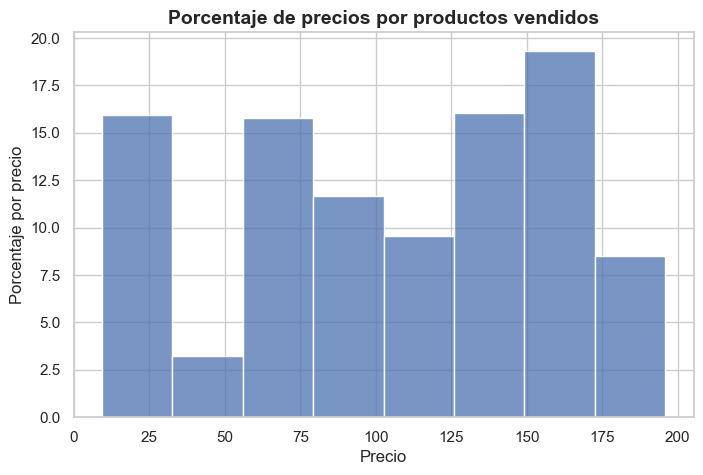

In [57]:
#Establecer el estilo del grafico y el tamaño
sns.set_theme(style="whitegrid") 

plt.figure(figsize=(8, 5))

# Titulos y nombre de eje Y

plt.title("Porcentaje de precios por productos vendidos", fontsize=14, fontweight="bold")

plt.ylabel("Porcentaje por precio", fontsize=12)
plt.xlabel("Precio", fontsize=12)


#Crear grafico, con eje x, 8 rangos de precio y agrupando por porcentaje
sns.histplot(df_ventas, x="price", bins=8, stat='percent') 
plt.show()

In [58]:
#Creo una columna agrupando por los rangos de precio para poder mostrar una tabla complementaria al grafico
df_ventas['price_bins'] = pd.cut(df_ventas['price'], bins=8)
# Calcular el porcentaje de productos vendidos por rango de precios
price_distribution = df_ventas['price_bins'].value_counts(normalize=True) * 100
# Convertir a un DataFrame
price_distribution_df = price_distribution.reset_index().round(2)
price_distribution_df.columns = ['Rango de Precios', 'Porcentaje de Productos Vendidos']
# Formatear los rangos de precios
price_distribution_df['Rango de Precios'] = price_distribution_df['Rango de Precios'].apply(lambda x: f'({x.left:.2f}, {x.right:.2f}]')
# Convertir el porcentaje a string y añadir el símbolo de porcentaje
price_distribution_df['Porcentaje de Productos Vendidos'] = price_distribution_df['Porcentaje de Productos Vendidos'].astype(str) + "%"
# Ordenar por rango de precios
price_distribution_df = price_distribution_df.sort_values(by='Rango de Precios')

price_distribution_df

,Rango de Precios,Porcentaje de Productos Vendidos
2,"(9.05, 32.58]",15.94%
7,"(32.58, 55.91]",3.24%
3,"(55.91, 79.25]",15.78%
4,"(79.25, 102.59]",11.65%
5,"(102.59, 125.93]",9.55%
1,"(125.93, 149.26]",16.02%
0,"(149.26, 172.60]",19.34%
6,"(172.60, 195.94]",8.5%


En este grafico (con la tabla de soporte) podemos ver la distribucion de los precios de los productos vendidos, con productos de (149.26, 172.60) los mas vendidos con casi el 20% mientras que los de (32.58, 55.91) los que menos se venden con 3.24%	

### Exercici 2 Dues variables numèriques.
https://seaborn.pydata.org/generated/seaborn.boxplot.html

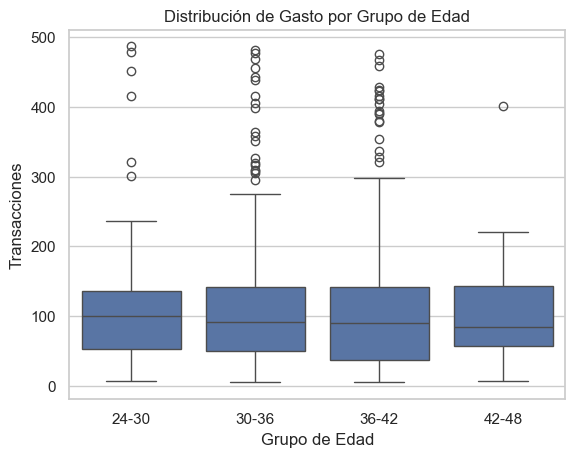

In [59]:
#Creo una columna asignando un rango de edad desde 24 a 48 
df_ventas["rango_edad"] = pd.cut(df_ventas["Edad"], bins=[24,30,36,42,48], labels=["24-30", "30-36", "36-42", "42-48"])

#uso el Rango para graficar vs amount (parte de una variable numerica aunque la conviertas a categorica)
sns.boxplot(x="rango_edad", y="amount", data=df_ventas) #Creo el grafico (boxplot) con los rangos en el eje x y amount en y
#Etiqueto ambos ejes y asigno titulo
plt.xlabel("Grupo de Edad")
plt.ylabel("Transacciones")
plt.title("Distribución de Gasto por Grupo de Edad")
#Muestro el grafico
plt.show()

In [60]:
df_ventas.groupby("rango_edad")["amount"].describe().round(2) #Muestro los valores descriptivos agrupados por edad para entender el grafico


,count,mean,std,min,25%,50%,75%,max
rango_edad,,,,,,,,
24-30,182.0,107.55,78.31,7.39,52.96,99.32,135.31,486.54
30-36,464.0,107.09,81.47,5.30,50.01,91.92,141.88,481.75
36-42,363.0,107.53,92.75,4.60,36.40,89.22,141.80,476.33
42-48,100.0,100.75,64.35,6.74,57.15,83.89,143.50,400.52


En general, se puede observar que, independientemente del grupo de edad, la media del gasto es bastante similar, alrededor de 107, con algunas variaciones en los valores mínimos y máximos. Las desviaciones estándar indican que hay bastante variabilidad en el gasto dentro de cada grupo de edad.
PS: al tener el campo amount distribuido por transacciones (debido a la falta de congruencia de los datos y la agrupacion de products ids) los valores real no son exactamente los distribuidos por transaccionya que la media se hace sobre cada prodcuto (menor) que si se hiciera por cada transaccion total

### Exercici 3 Una variable categòrica.
https://seaborn.pydata.org/generated/seaborn.barplot.html

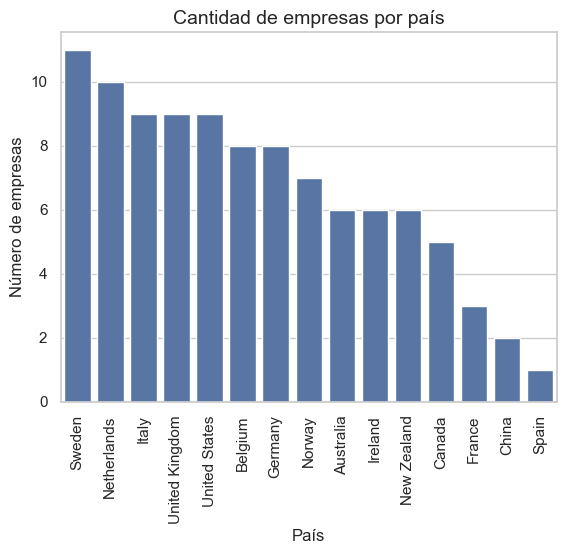

In [61]:
#Calculo dentro de los datos la cantidad de empresas unicas por pais 
sns.barplot(
    data=df_ventas.groupby("country_Company")["company_name"].nunique().reset_index(name="num_empresas").sort_values('num_empresas', ascending=False),
    x="country_Company",
    y="num_empresas",
    order=df_ventas.groupby("country_Company")["company_name"].nunique().reset_index(name="num_empresas").sort_values('num_empresas', ascending=False).country_Company #Ordeno por paises con mas empresas
)

# Mejorar la visualización: rotar etiquetas, aumentar tamaño, etc.
plt.xticks(rotation=90)  # Usa las etiquetas en vertical para poder verlas
plt.title("Cantidad de empresas por país", fontsize=14)  # Título del gráfico
plt.xlabel("País", fontsize=12)  # Etiqueta del eje X
plt.ylabel("Número de empresas", fontsize=12)  # Etiqueta del eje Y
plt.show()



In [62]:
#Creo un df para mostrar los datos en formato tabla 
Company_Pais = df_ventas.groupby("country_Company")["company_name"].nunique().reset_index(name="num_empresas").sort_values('num_empresas', ascending= False)
Company_Pais

,country_Company,num_empresas
12,Sweden,11
8,Netherlands,10
7,Italy,9
13,United Kingdom,9
14,United States,9
1,Belgium,8
5,Germany,8
10,Norway,7
0,Australia,6
6,Ireland,6


En este grafico de barras, podemos ver la distribucion de las empresas en los paises, donde Sweden es el pais con mas empresas (11), mientras que espana es el que menos (1)

### Exercici 4 Una variable categòrica i una numèrica.
https://plotly.com/python/bar-charts/?form=MG0AV3


In [63]:
#Asigno la agrupacion de los dias a "data" para graficar por dias sumand solo las variables numericas ya que me interesa solo el amount 
data = df_ventas.groupby("dia").sum(numeric_only=True).reset_index()
#Creo el grafico y lo ordeno por los dias de la semana 
fig = px.bar(data, x='dia', y='amount', title='Ventas por Día de la Semana', category_orders={"dia": ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']})
fig.update_layout(xaxis_title='Día de la Semana', yaxis_title='Monto de Ventas')
fig.show()


En este grafico interactivo (plotly) podemos ver la distribucion de las ventas a lo largo de la semana, encontramos que los lunes es el dia que mas se compra, va disminuyendo en la semana y el viernes es el dia menos productivo

### Exercici 5 Dues variables categòriques
https://plotly.com/python/bar-charts/

In [64]:
# Agrupar y contar las ventas por país y producto
top_products = df_ventas.groupby(["country_Company", "product_name"]).size().reset_index(name="count")

# Filtrar solo los 10 productos más vendidos por país
top_products = top_products.groupby("country_Company").apply(lambda x: x.nlargest(10, "count")).reset_index(drop=True)

# Crear el gráfico
fig = px.bar(top_products, x="country_Company", y="count", color="product_name", barmode="group",
             title="Top 10 Productos más vendidos por País")
fig.show()



En este, contamos los 10 productos mas vendidos por pais, y lo mostramos en un grafico de barras interactivo, donde podemos seleccionar un pais o varios y ver cuales son los productos mas vendidos de ese pais. Idealmente, podemos hacer zoom sobre los paises que nos interesan para tener un analisis mas detallado.

### Exercici 6 Tres variables.

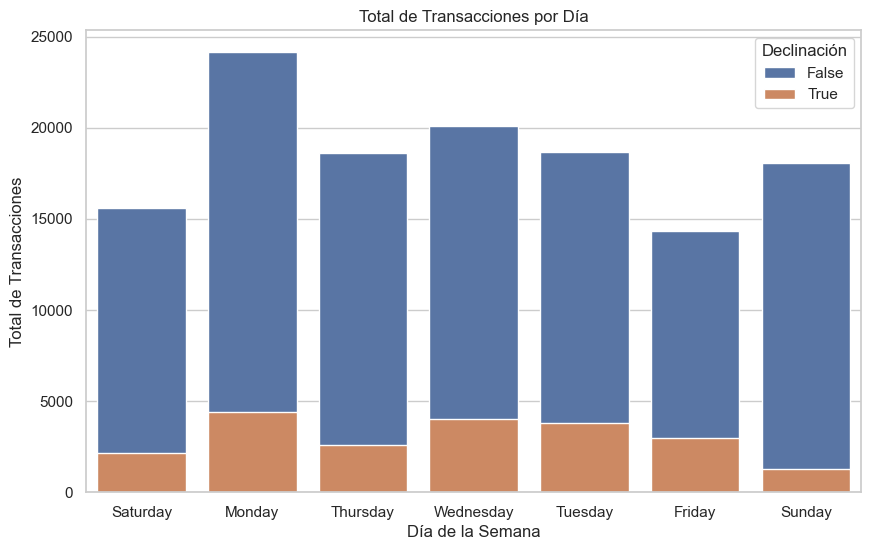

In [65]:
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Crear el gráfico de barras
sns.barplot(data=df, x="dia", y="amount", hue="declined", dodge=False, ci=False, estimator=np.sum)

# Añadir títulos y etiquetas
plt.title("Total de Transacciones por Día")
plt.xlabel("Día de la Semana")
plt.ylabel("Total de Transacciones")
plt.legend(title="Declinación")

# Mostrar el gráfico
plt.show()


En este grafico, vemos el total de ventas, cada dia de la semana dividido entre las declinadas y las que no han sido declinadas, para tener una vision de cuanto se vende en la semana y que porcentaje se acepta o no

### Exercici 7 Graficar un Pairplot.
https://seaborn.pydata.org/generated/seaborn.pairplot.html

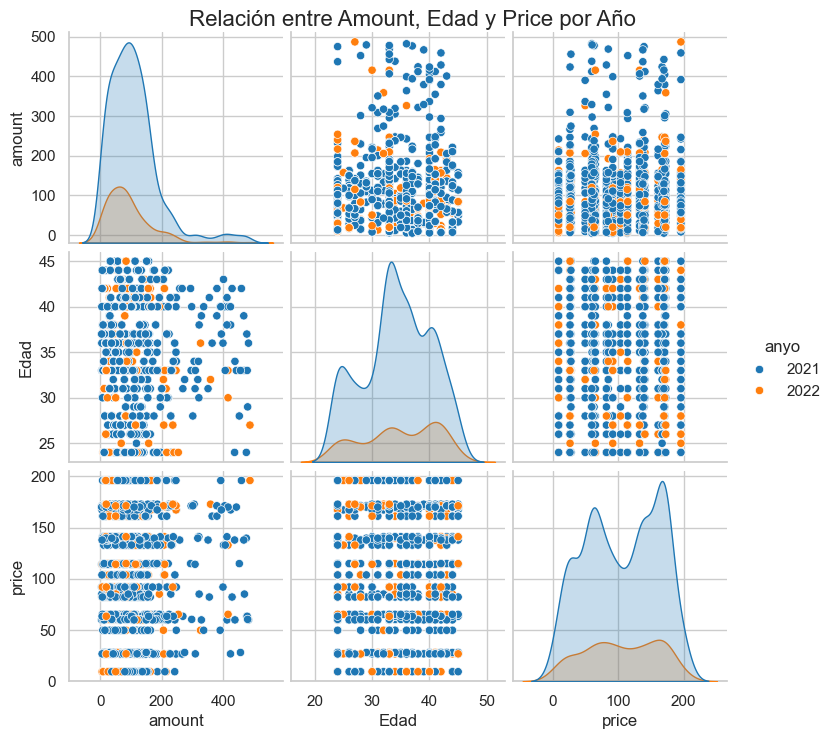

In [66]:
#Creo el pairplot, pero solo tomando en cuenta amount, edad y price
sns.pairplot(df_ventas,  x_vars=["amount", "Edad", "price"], y_vars=["amount", "Edad", "price"], hue="anyo", palette="tab10")

plt.suptitle("Relación entre Amount, Edad y Price por Año", fontsize=16)

plt.subplots_adjust(top=0.95)  # Ajuste para no superponer el título

plt.show()

Aqui generamos un pairplot (no con todas las numericas, ya que por ejemplo, lat y longitude no aportan) donde podemos ver las relaciones entre amount, edad y Price, categorizado por año (aunque al no tener datos completos, la informacion no es completa), pero si tenemos indicadores como el pico de edad cerca de 35 años, la tendencia bimodal del precio, etc

## Nivel 2 

### Exercici 1 Correlació de totes les variables numèriques.
https://datatab.es/tutorial/correlation

In [67]:
#Creo un DF con solo mis variables numericas
df_numericas = df_ventas.select_dtypes(include ='number')#.style.background_gradient('coolwarm')
#Creo una matriz de correlacion con el DF
corr_matrix = df_numericas.corr()


In [68]:
threshold = 0.3 #Discrimino correlaciones de mas de 0.3
mask = np.abs(corr_matrix) < threshold 
corr_matrix_filtered = corr_matrix.mask(mask)  # Aplicar filtro
corr_matrix_estilo = corr_matrix_filtered.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1)
corr_matrix_estilo
#Muestro la matriz, pero que no tiene muchos resultados con correlaciones 

,amount,lat,longitude,anyo,Edad,price,weight,mes
amount,1.000000,nan,nan,nan,nan,nan,nan,nan
lat,nan,1.000000,nan,nan,nan,nan,nan,nan
longitude,nan,nan,1.000000,nan,nan,nan,nan,nan
anyo,nan,nan,nan,1.000000,nan,nan,nan,-0.669664
Edad,nan,nan,nan,nan,1.000000,nan,nan,nan
price,nan,nan,nan,nan,nan,1.000000,nan,nan
weight,nan,nan,nan,nan,nan,nan,1.000000,nan
mes,nan,nan,nan,-0.669664,nan,nan,nan,1.000000


En este generamos una matriz de correlacion con correlaciones mayores a 0.3, pero no encontramos casi datos d correlaciones positivas ni negativas.

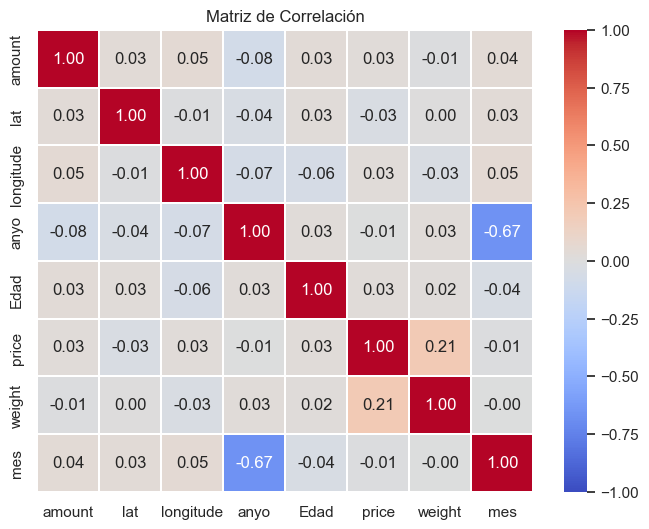

In [69]:
#Ahora si genereamos un heatmap para mostrar la matriz de correlaciones, pero sin filtrar por correlaciones bajas 
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.1, vmin=-1, vmax=1)
plt.title("Matriz de Correlación")
plt.show()

Aqui si generamos la matriz de correlacion dde todas las variables numericas con todas las correlaciones (sin excluir las pequeñas) y tenemos pocas correlaciones entre variables, donde tenemos una correlacion negativa con los años, se puede deber mas que a una correlacion real a la falta de datos

### Exercici 2 Implementa un jointplot.

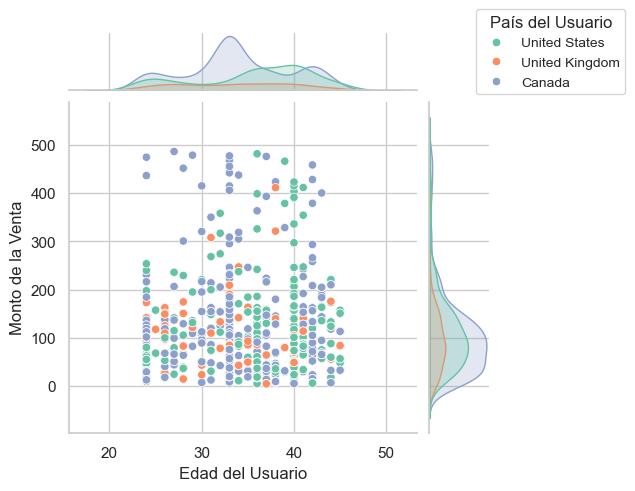

In [70]:
# Crear el jointplot 
g = sns.jointplot(data=df_ventas, x="Edad", y="amount", hue="country_user", palette="Set2")

g.fig.set_size_inches(6, 5)

# Modificar las etiquetas
g.set_axis_labels("Edad del Usuario", "Monto de la Venta", fontsize=12)

# Mover la leyenda
g.ax_joint.legend(title="País del Usuario", loc='upper left', bbox_to_anchor=(1.15, 1.3), fontsize=10)

# Ajustar márgenes
g.fig.subplots_adjust(top=1, right=0.9, left=0.2, bottom=0.2)

# Mostrar el gráfico
plt.show()



EN este jointplot, comparamos los montos de ventas por edad categorizado por pais, en el plot principal tenemos la distribucion bastante equitativa donde vemos que canada hace transacciones por mayor monto distribuida en todas las edades. En los secundarios, tenemos para edad el pico en el centro de canada, una tendencia a mayores usuarios en Estados Unidos y en el Reino Unido mas distribuid, mientras que por montos, tenemos una distribucion de los 3 paises en montos menores.

## Nivel 3

### Exercici 1 Implementa un violinplot combinat amb un altre tipus de gràfic.

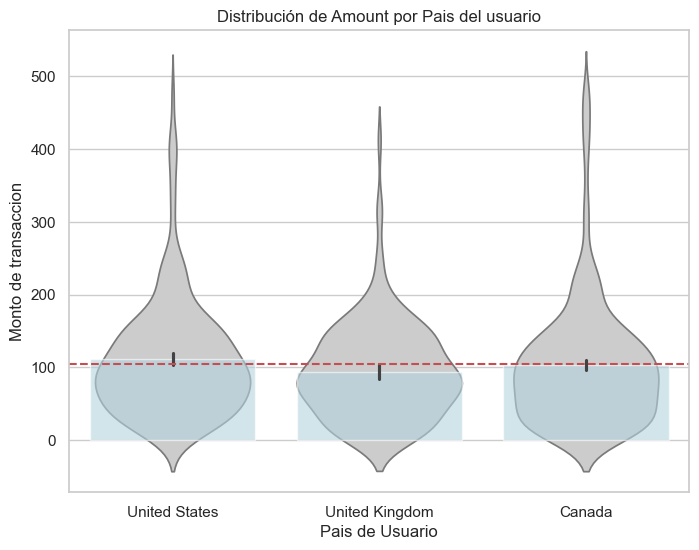

In [71]:
plt.figure(figsize=(8, 6))
#Creamos el violinplot con pais del usuario vs amount para ver la distribucion
sns.violinplot(x='country_user', y='amount', data=df_ventas, inner=None, color=".8")
#Y el barploot encima para ver las medias por  pais 
sns.barplot(x='country_user', y='amount', data=df_ventas, color='lightblue', alpha=0.6)
#Creamos una linea de media general entre todos los usuarions (sin agrupar por pais)
plt.axhline(y=df_ventas['amount'].mean(), color='r', linestyle='--')

plt.title('Distribución de Amount por Pais del usuario')
plt.xlabel('Pais de Usuario')
plt.ylabel('Monto de transaccion')

plt.show()


En este grafico combinamos un violinplot con un grafico de barras que complementa al primero, nos muestra la distribucion de medias en los paises comparado con su distrucion, asi como una linea de media general donde vemos que Canada esta en toda la media, Reino Unido ligeramente por debajo y Estados Unidos ligeramente arriba.

### Exercici 2 Genera un FacetGrid per a visualitzar múltiples aspectes de les dades simultàniament.

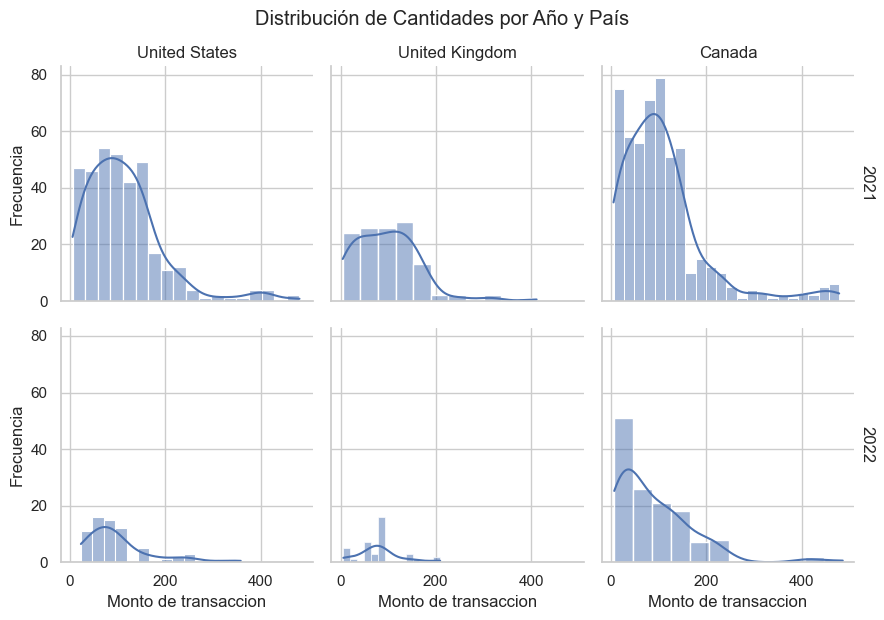

In [72]:
#Creo y asigno el facetgrid a una variable
g = sns.FacetGrid(df_ventas, col="country_user", row="anyo", margin_titles=True)
#Con el facetgrid, utilizo un histplot para cada grafico individual
g.map(sns.histplot, "amount", kde=True)

g.fig.suptitle("Distribución de Cantidades por Año y País", y=1.03)
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set_axis_labels("Monto de transaccion", "Frecuencia")

plt.show()



En este Facetgrid, vemos la distribucion de las transacciones, comparadas por año y por Pais, los datos no son muy completos para sacar buenas conclusiones, pero vemos como  en todos los paises y todos los años, hay mas tendencias a transacciones de menor monto con mas o menos variacion segun los paises